<a href="https://colab.research.google.com/github/KURISANI/Traffic-Sign-Classification/blob/main/Traffic_signs_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model that can be used by smart cars to classify traffic signs
Convolutional Neutal network using Tensorflow and Keras

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mccauleymabedhle","key":"ef878b9b613b029edc0e5cb5651d7391"}'}

In [ ]:
!pip install -q kaggle


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# setting up kaggle using Kaggle API
#creating directory and changing the work directory
!mkdir traffic_sign_dataset
%cd traffic_sign_dataset

/content/traffic_sign_dataset


In [ ]:
# search for dataset
!kaggle datasets list -s gtsrb-german-traffic-sign

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
meowmeowmeowmeowmeow/gtsrb-german-traffic-sign                     GTSRB - German Traffic Sign Recognition Benchmark    641568792  2018-11-25 18:12:34.427000         180151       1333  0.8235294        
valentynsichkar/traffic-signs-preprocessed                         Traffic Signs Preprocessed                          4471088826  2019-08-31 18:22:11.850000          21556        334  1                
harbhajansingh21/german-traffic-sign-dataset                       German Traffic Sign Dataset                          123621493  2023-07-11 04:21:24.180000           3713         42  1  

In [ ]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:04<00:00, 134MB/s]



In [ ]:
!unzip /content/traffic_sign_dataset/gtsrb-german-traffic-sign.zip -d traffic_sign_dataset
!rm /content/traffic_sign_dataset/gtsrb-german-traffic-sign.zip
!rm -rf traffic_sign_dataset/Meta
!rm -rf traffic_sign_dataset/meta
!rm -rf traffic_sign_dataset/test
!rm -rf traffic_sign_dataset/train
!rm -rf traffic_sign_dataset/Meta.csv

Streaming output truncated to the last 5000 lines.
  inflating: traffic_sign_dataset/train/5/00005_00053_00010.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00011.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00012.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00013.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00014.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00015.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00016.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00017.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00018.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00019.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00020.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00021.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00022.png  
  inflating: traffic_sign_dataset/train/5/00005_00053_00023.png  
  inflating: traffic_sign

In [ ]:
#import sys
#!{sys.executable} -m pip install --upgrade tensorflow

Traceback (most recent call last):
  File 
"/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", 
line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File 
"/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line
67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File 
"/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", 
line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File 
"/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/res
olver.py", line 179, in resolve
    self.factory.preparer.prepare_linked_requirements_more(reqs)
  File 
"/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/prepare.py", 
line 554, in prepare_linked_requirements_more
    self._complete_partial_requirements(
  File 
"/usr/local/lib/python3.12/dist-packages/pip/_internal/ope

In [ ]:
# Importing libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns
import random
from PIL import Image
from sklearn.model_selection import  train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPool2D

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


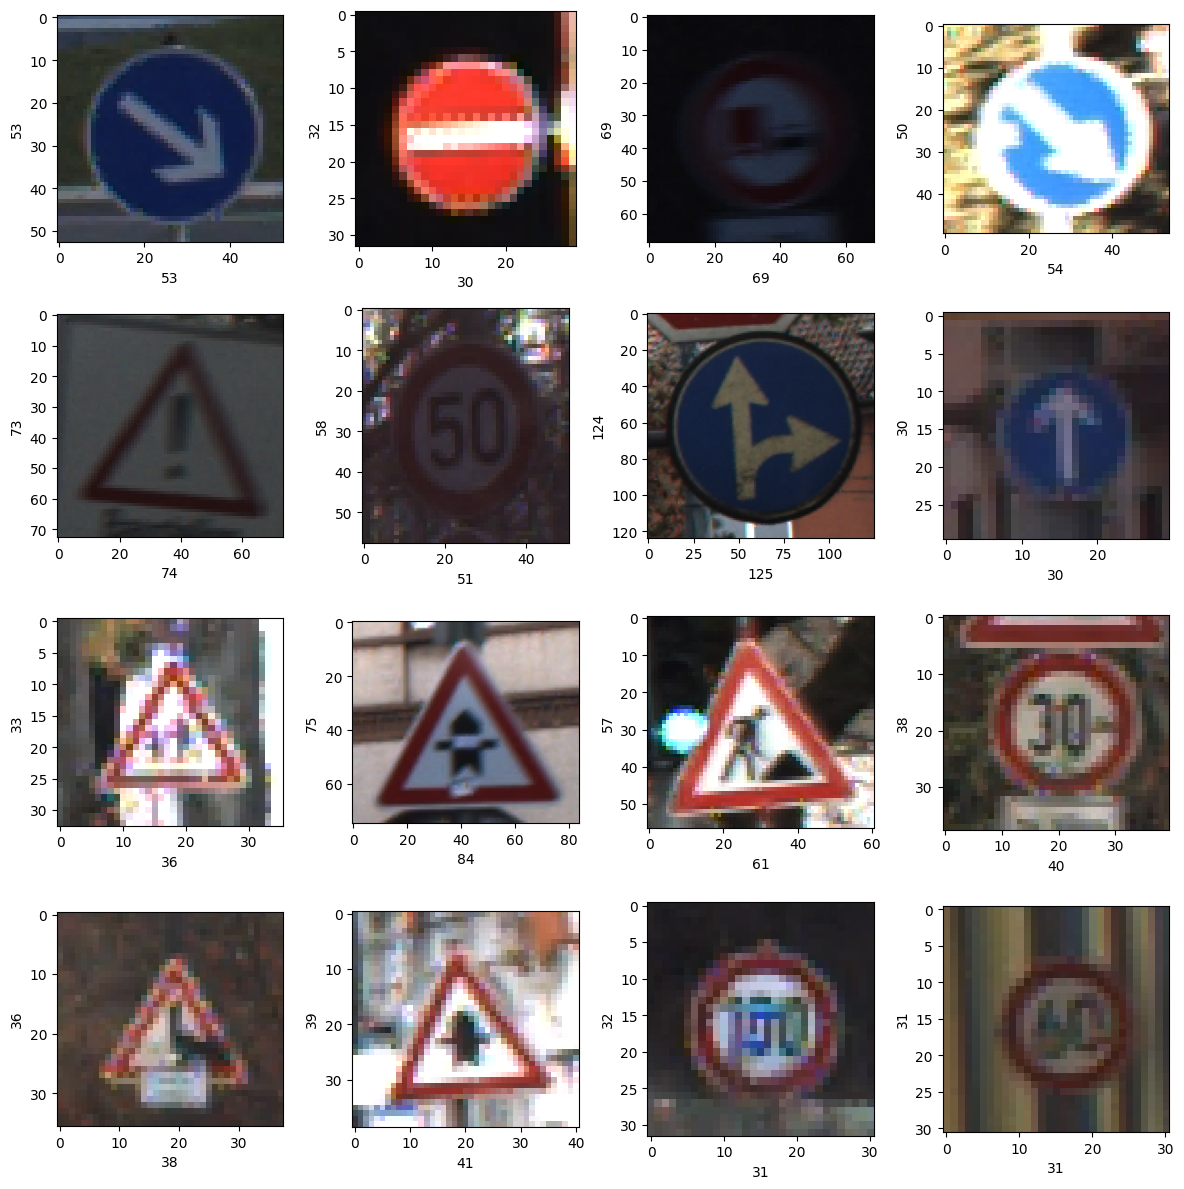

In [ ]:
# plot 12 images
plt.figure(figsize=(12,12))
path="traffic_sign_dataset/Test"
for i in range(1,17):
  plt.subplot(4,4,i)
  plt.tight_layout()
  rand_img = plt.imread(path + "/" + random.choice(os.listdir(path)))
  plt.imshow(rand_img)
  plt.xlabel(rand_img.shape[1], fontsize = 10)
  plt.ylabel(rand_img.shape[0], fontsize = 10)

In [ ]:
dim1 = []
dim2 = []

for i in range(1,43):
  labels = "traffic_sign_dataset/Train/" + "/{0}".format(i)
  image_path = os.listdir(labels)
  for x in image_path:
    img = plt.imread(labels + "/" + x)
    dim1.append(img.shape[0])
    dim2.append(img.shape[1])


In [ ]:
# mean demension of images
print(f"demension 1 mean: {np.mean(dim1)}  demension 2 mean: {np.mean(dim2)}")

demension 1 mean: 50.30993102387241  demension 2 mean: 50.824713454191134


In [ ]:
# reshape images to (50,50)
images = []
label_id = []

for i in range(43):
  labels = "traffic_sign_dataset/Train/" + "/{0}".format(i)
  image_path = os.listdir(labels)
  for x in image_path:
    img = Image.open(labels + "/" + x)
    img = img.resize((50,50))
    img = np.array(img)
    images.append(img)
    label_id.append(i)

In [ ]:
#Normalization

images = np.array(images)
images = images/255
label_id = np.array(label_id)
label_id.shape

(39209,)

In [ ]:
# classes count
label_counts = pd.DataFrame(label_id).value_counts()
label_counts.head()

,count
0,
2,2250
1,2220
13,2160
12,2100
38,2070


In [ ]:
#splitting the data
x_train, x_val, y_train, y_val = train_test_split(images, label_id, test_size=0.2, random_state=42)

In [ ]:
# one-hot encoding
y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)

In [ ]:
model = Sequential()

model.add(Conv2D(filters= 64, kernel_size =(3,3), input_shape= x_train.shape[1:], activation="relu", padding="same"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters= 64, kernel_size=(3,3), activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(128, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(43, activation = "softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss = "sparse_categorical_crossentropy", optimizer= "adam", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 23, 23, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       991,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,035,627 (3.95 MB)

 Trainable params: 1,035,627 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train, y_train, epochs=50, batch_size=128, validation_data=(x_val, y_val), verbose=2)

Epoch 1/50
246/246 - 225s - 917ms/step - accuracy: 0.4432 - loss: 2.0481 - val_accuracy: 0.8315 - val_loss: 0.6425
Epoch 2/50
246/246 - 249s - 1s/step - accuracy: 0.7508 - loss: 0.8104 - val_accuracy: 0.9402 - val_loss: 0.3107
Epoch 3/50
246/246 - 208s - 846ms/step - accuracy: 0.8341 - loss: 0.5361 - val_accuracy: 0.9694 - val_loss: 0.1628
Epoch 4/50
246/246 - 272s - 1s/step - accuracy: 0.8643 - loss: 0.4334 - val_accuracy: 0.9745 - val_loss: 0.1304
Epoch 5/50
246/246 - 209s - 849ms/step - accuracy: 0.8882 - loss: 0.3583 - val_accuracy: 0.9807 - val_loss: 0.1123
Epoch 6/50
246/246 - 269s - 1s/step - accuracy: 0.9067 - loss: 0.2985 - val_accuracy: 0.9833 - val_loss: 0.0846
Epoch 7/50
246/246 - 217s - 881ms/step - accuracy: 0.9158 - loss: 0.2650 - val_accuracy: 0.9872 - val_loss: 0.0697
Epoch 8/50
246/246 - 216s - 878ms/step - accuracy: 0.9250 - loss: 0.2412 - val_accuracy: 0.9847 - val_loss: 0.0715
Epoch 9/50
246/246 - 261s - 1s/step - accuracy: 0.9302 - loss: 0.2210 - val_accuracy: 0.9

<Axes: >

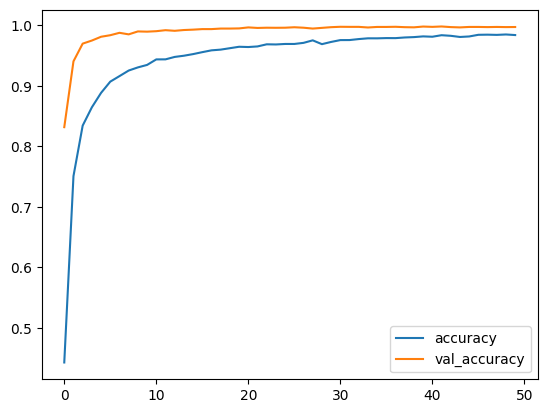

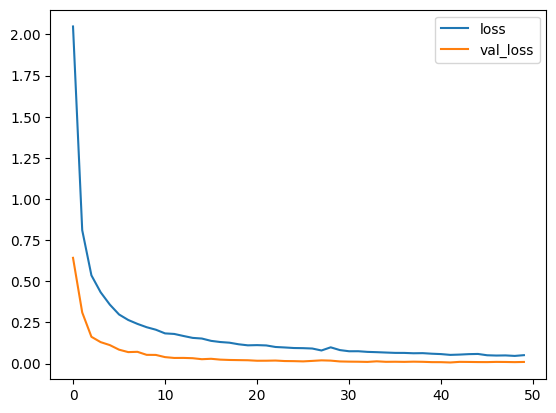

In [ ]:
evaluation = pd.DataFrame(model.history.history)
evaluation[["accuracy", "val_accuracy"]].plot()
evaluation[["loss", "val_loss"]].plot()

In [ ]:
test_path = '/content/traffic_sign_dataset/traffic_sign_dataset/Test'
!rm /content/traffic_sign_dataset/traffic_sign_dataset/Test/GT-final_test.csv

In [ ]:
from PIL import Image

def scaling(test_images, test_path):
  images = []

  image_path = test_images

  for x in image_path:
    img = Image.open(test_path + "/" + x)
    img = img.resize((50,50))
    img = np.array(img)
    images.append(img)

  images = np.array(images)
  images = images/255
  return images

In [ ]:
test_images = scaling(sorted(os.listdir(test_path)), test_path)

In [ ]:
test = pd.read_csv('traffic_sign_dataset/Test.csv')
y_test = test['ClassId'].values
y_test


array([16,  1, 38, ...,  6,  7, 10])

In [ ]:
y_pred_prob = model.predict(test_images)
y_pred = np.argmax(y_pred_prob, axis=1)
y_pred

395/395 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step


array([16,  1, 38, ..., 38,  7, 10])

In [ ]:
# Storing all lables
all_lables = ['Speed limit (20km/h)','Speed limit (30km/h)','Speed limit (50km/h)','Speed limit (60km/h)',
              'Speed limit (70km/h)','Speed limit (80km/h)','End of speed limit (80km/h)','Speed limit (100km/h)',
              'Speed limit (120km/h)','No passing','No passing for vechiles over 3.5 metric tons',
              'Right-of-way at the next intersection','Priority road','Yield','Stop','No vechiles',
              'Vechiles over 3.5 metric tons prohibited','No entry','General caution','Dangerous curve to the left',
              'Dangerous curve to the right','Double curve','Bumpy road','Slippery road','Road narrows on the right',
              'Road work','Traffic signals','Pedestrians','Children crossing','Bicycles crossing','Beware of ice/snow',
              'Wild animals crossing','End of all speed and passing limits','Turn right ahead','Turn left ahead',
              'Ahead only','Go straight or right','Go straight or left','Keep right','Keep left','Roundabout mandatory',
              'End of no passing','End of no passing by vechiles over 3.5 metric']

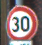

In [ ]:
# Visualize test image
img = Image.open(test_path + '/00001.png')
img

In [ ]:
# Original label
print("Original label : ",all_lables[y_test[1]])

Original label :  Speed limit (30km/h)


In [ ]:
# Predicted label
print("Predicted label : ",all_lables[y_pred[1]])

Predicted label :  Speed limit (30km/h)


#Conclusion


I started with downloading the dataset, preprocessing it, created the model and found out the predictions using the model. During preprocessing I found that this dataset has 43 classes. Model reached an accuracy of 95%+ in just 50 epochs, I can further optimize the model using hyperparameter tuning and reach a higher accuracy.